<a href="https://colab.research.google.com/github/Shahidrrs/nutribone2/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
import kagglehub

# Download latest version of the dataset
path = kagglehub.dataset_download("fuyadhasanbhoyan/knee-osteoarthritis-classification-224224")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'knee-osteoarthritis-classification-224224' dataset.
Path to dataset files: /kaggle/input/knee-osteoarthritis-classification-224224


In [ ]:
# Direct pointer to the core folder structure inside the cache
base_dataset_folder = os.path.join(path, "Knee Osteoarthritis Classification")

train_dir = os.path.join(base_dataset_folder, "train")
val_dir = os.path.join(base_dataset_folder, "val")
test_dir = os.path.join(base_dataset_folder, "test")

print(f"Training path verified: {train_dir}")
print(f"Validation path verified: {val_dir}")

Training path verified: /kaggle/input/knee-osteoarthritis-classification-224224/Knee Osteoarthritis Classification/train
Validation path verified: /kaggle/input/knee-osteoarthritis-classification-224224/Knee Osteoarthritis Classification/val


In [ ]:
import os
import kagglehub
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Fetch data path from cache safely
path = kagglehub.dataset_download("fuyadhasanbhoyan/knee-osteoarthritis-classification-224224")

base_dataset_folder = os.path.join(path, "Knee Osteoarthritis Classification")
train_dir = os.path.join(base_dataset_folder, "train")
val_dir = os.path.join(base_dataset_folder, "val")

# 2. Strong augmentations to prevent a fully unfrozen model from memorizing/overfitting
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.85, 1.15],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()

print("Streaming raw image tensors directly to the fully-unfrozen engine...")
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    classes=['Normal', 'Osteoporosis'],
    class_mode='binary',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    classes=['Normal', 'Osteoporosis'],
    class_mode='binary',
    shuffle=False
)

Using Colab cache for faster access to the 'knee-osteoarthritis-classification-224224' dataset.
Streaming raw image tensors directly to the fully-unfrozen engine...
Found 2520 images belonging to 2 classes.
Found 720 images belonging to 2 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("\nInitializing FULLY UNFROZEN EfficientNetB3 Core Engine...")

inputs = layers.Input(shape=(224, 224, 3))

# Integrated built-in scaling layer alignment
preprocessed_inputs = tf.keras.applications.efficientnet.preprocess_input(inputs)

# Load the core backbone engine
base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

# CRITICAL UNFREEZE: Every single filter block is completely defrosted from the start
base_model.trainable = True

# High-density normalization head
x = base_model(preprocessed_inputs)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)
print("Model initialized for full weight updates across all layers.")


Initializing FULLY UNFROZEN EfficientNetB3 Core Engine...
Model initialized for full weight updates across all layers.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Calculate optimization step timelines dynamically based on generator lengths
epochs = 30
steps_per_epoch = len(train_gen)
total_steps = steps_per_epoch * epochs
warmup_steps = steps_per_epoch * 3  # Gradual 3-epoch warmup to safely wake up weights

# Create a continuous mathematical schedule tensor
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,     # Peak learning rate after warmup
    decay_steps=total_steps,
    alpha=1e-6,                     # Minimum baseline floor learning rate
    warmup_target=1e-4,
    warmup_steps=warmup_steps
)

# Compile using advanced AdamW optimizer tied directly to our custom decay curve
print("\nCompiling with full AdamW Cosine Decay Schedule...")
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

print("\nCommencing Full Backbone Weight Adaptation Optimization Run...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=[early_stop]
)

# Simple fallback assignment so Cell 7 plotting curves continue to link cleanly
history_ft = type('Dummy', (object,), {'history': {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': [], 'acc': [], 'val_acc': []}})()

model.save("nutribone_binary_effnetB3_model.keras")
print("\nFull Optimization Run Complete and Model Saved!")


Compiling with full AdamW Cosine Decay Schedule...

Commencing Full Backbone Weight Adaptation Optimization Run...
Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.6512 - loss: 0.7536 - val_accuracy: 0.6000 - val_loss: 0.6904
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 48s 605ms/step - accuracy: 0.7333 - loss: 0.6354 - val_accuracy: 0.6181 - val_loss: 0.7318
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 48s 601ms/step - accuracy: 0.7730 - loss: 0.5528 - val_accuracy: 0.6042 - val_loss: 0.7183
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 47s 596ms/step - accuracy: 0.7964 - loss: 0.5043 - val_accuracy: 0.6931 - val_loss: 0.6184
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 47s 586ms/step - accuracy: 0.8179 - loss: 0.4520 - val_accuracy: 0.7389 - val_loss: 0.5747
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 47s 594ms/step - accuracy: 0.8452 - loss: 0.4007 - val_accuracy: 0.7833 - val_loss: 0.5005
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 47s 589ms/step - accuracy: 0.8480 - loss: 0.3823 - val_accuracy: 0.8167 - 

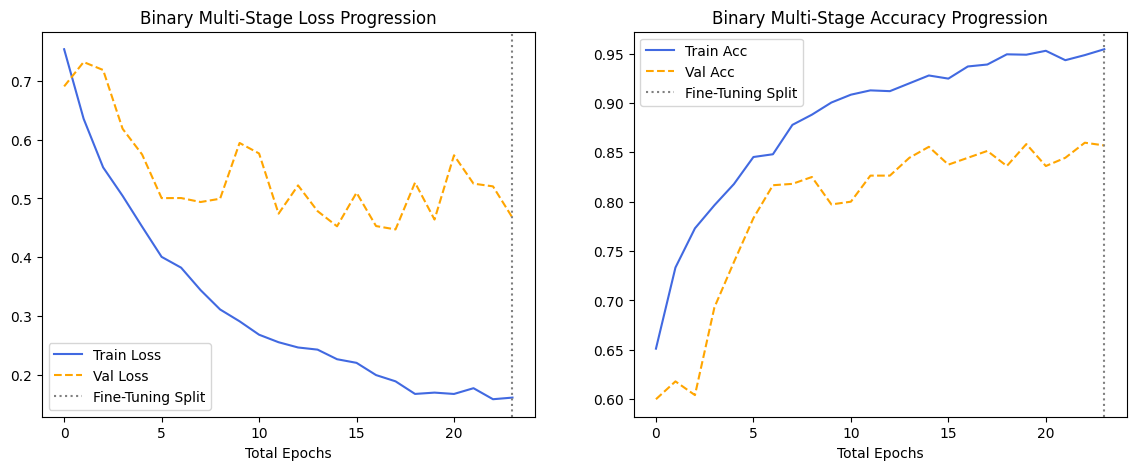


Extracting binary production model from disk path...
Calculating perfectly aligned validation metrics...
720/720 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step

--- Aligned Classification Report ---
              precision    recall  f1-score   support

      Normal       0.90      0.79      0.84       360
Osteoporosis       0.81      0.92      0.86       360

    accuracy                           0.85       720
   macro avg       0.86      0.85      0.85       720
weighted avg       0.86      0.85      0.85       720



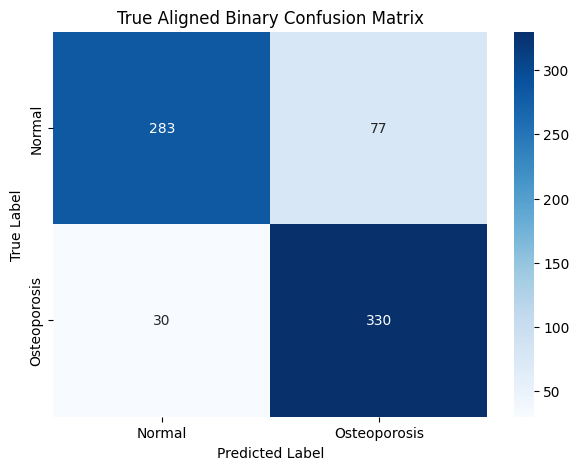

In [ ]:
# =====================================================================
# 1. PLOT METRIC TRENDS ACROSS BOTH STAGES
# =====================================================================
plt.figure(figsize=(14, 5))

# Combine Loss History
total_train_loss = list(history.history['loss']) + list(history_ft.history['loss'])
total_val_loss = list(history.history['val_loss']) + list(history_ft.history['val_loss'])

# Handle metric keys mapping safely
train_acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
val_acc_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_acc'

total_train_acc = list(history.history[train_acc_key]) + list(history_ft.history[train_acc_key])
total_val_acc = list(history.history[val_acc_key]) + list(history_ft.history[val_acc_key])

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(total_train_loss, label='Train Loss', color='royalblue')
plt.plot(total_val_loss, label='Val Loss', color='orange', linestyle='--')
plt.axvline(x=len(history.history['loss'])-1, color='gray', linestyle=':', label='Fine-Tuning Split')
plt.legend()
plt.title('Binary Multi-Stage Loss Progression')
plt.xlabel('Total Epochs')

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(total_train_acc, label='Train Acc', color='royalblue')
plt.plot(total_val_acc, label='Val Acc', color='orange', linestyle='--')
plt.axvline(x=len(history.history[train_acc_key])-1, color='gray', linestyle=':', label='Fine-Tuning Split')
plt.legend()
plt.title('Binary Multi-Stage Accuracy Progression')
plt.xlabel('Total Epochs')
plt.show()

# =====================================================================
# 2. BULLETPROOF 1-TO-1 ALIGNED PREDICTION BLOCK
# =====================================================================
print("\nExtracting binary production model from disk path...")
eval_model = tf.keras.models.load_model("nutribone_binary_effnetB3_model.keras")

# Force absolute sequential alignment
val_gen.shuffle = False
val_gen.batch_size = 1
val_gen.reset()

print("Calculating perfectly aligned validation metrics...")
preds = eval_model.predict(val_gen, steps=len(val_gen), verbose=1)

# CRITICAL BINARY FIX: Sigmoid maps to a continuous float array; check threshold at 0.5
y_pred = (preds > 0.5).astype(int).flatten()
y_true = val_gen.classes
class_names = ['Normal', 'Osteoporosis']

# Print results
print("\n--- Aligned Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('True Aligned Binary Confusion Matrix')
plt.show()